In [1]:
"""
Final Ödevi - Uçtan Uca Makine Öğrenmesi Projesi

Proje Başlığı:
Öğrenci Yaşamında Yapay Zekâ Asistanı Kullanımı: Tekrar Kullanım Tahmini

Projenin Amacı:
Bu projede öğrencilerin bir yapay zekâ asistanını tekrar kullanıp kullanmayacağı,
oturum süresi, prompt sayısı, görev türü, yardım seviyesi ve memnuniyet puanı gibi
değişkenler kullanılarak tahmin edilmektedir.

Problem Türü:
Sınıflandırma (Classification)

Veri Seti:
ai_assistant_usage_student_life.csv

Kullanılan Kütüphaneler:

* pandas
* numpy
* matplotlib
* seaborn
* scikit-learn

Proje Adımları:

1. Veri setinin yüklenmesi ve incelenmesi
2. Veri ön işleme
3. Kategorik değişkenlerin dönüştürülmesi
4. Aykırı değer analizi
5. Öznitelik mühendisliği
6. Öznitelik seçimi
7. Verinin eğitim, doğrulama ve test kümelerine ayrılması
8. Birden fazla modelin eğitilmesi
9. Modellerin karşılaştırılması
10. Hiperparametre optimizasyonu
11. En iyi modelin test verisi üzerinde değerlendirilmesi
12. Sonuçların yorumlanması

Çalıştırma Adımları:

1. Gerekli kütüphaneleri yükleyin:
   pip install -r requirements.txt

2. Notebook veya Python dosyasını çalıştırın:
   jupyter notebook final_project.ipynb
   veya
   python final_project.py
   """


'\nFinal Ödevi - Uçtan Uca Makine Öğrenmesi Projesi\n\nProje Başlığı:\nÖğrenci Yaşamında Yapay Zekâ Asistanı Kullanımı: Tekrar Kullanım Tahmini\n\nProjenin Amacı:\nBu projede öğrencilerin bir yapay zekâ asistanını tekrar kullanıp kullanmayacağı,\noturum süresi, prompt sayısı, görev türü, yardım seviyesi ve memnuniyet puanı gibi\ndeğişkenler kullanılarak tahmin edilmektedir.\n\nProblem Türü:\nSınıflandırma (Classification)\n\nVeri Seti:\nai_assistant_usage_student_life.csv\n\nKullanılan Kütüphaneler:\n\n* pandas\n* numpy\n* matplotlib\n* seaborn\n* scikit-learn\n\nProje Adımları:\n\n1. Veri setinin yüklenmesi ve incelenmesi\n2. Veri ön işleme\n3. Kategorik değişkenlerin dönüştürülmesi\n4. Aykırı değer analizi\n5. Öznitelik mühendisliği\n6. Öznitelik seçimi\n7. Verinin eğitim, doğrulama ve test kümelerine ayrılması\n8. Birden fazla modelin eğitilmesi\n9. Modellerin karşılaştırılması\n10. Hiperparametre optimizasyonu\n11. En iyi modelin test verisi üzerinde değerlendirilmesi\n12. Sonuçlar

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ai_assistant_usage_student_life.csv to ai_assistant_usage_student_life.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style('whitegrid')

In [4]:
df=pd.read_csv("ai_assistant_usage_student_life.csv")

In [5]:
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [6]:
df.shape #veri setimizin yapısını inceliyoruz, 10000 satır ve 11 sütun

(10000, 11)

In [7]:
df.dtypes

,0
SessionID,object
StudentLevel,object
Discipline,object
SessionDate,object
SessionLengthMin,float64
TotalPrompts,int64
TaskType,object
AI_AssistanceLevel,int64
FinalOutcome,object
UsedAgain,bool


In [8]:
df.describe()  #temel istatistiksel özellikleri inceliyoruz

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.846467,5.607500,3.479500,3.417780
std,13.897302,4.648764,0.991805,1.143331
min,0.030000,1.000000,1.000000,1.000000
25%,9.630000,2.000000,3.000000,2.600000
50%,16.650000,4.000000,4.000000,3.500000
75%,26.670000,8.000000,4.000000,4.400000
max,110.810000,39.000000,5.000000,5.000000


In [9]:
df.describe(include='object')

,SessionID,StudentLevel,Discipline,SessionDate,TaskType,FinalOutcome
count,10000,10000,10000,10000,10000,10000
unique,10000,3,7,366,6,4
top,SESSION09984,Undergraduate,Biology,2025-01-19,Writing,Assignment Completed
freq,1,5978,1458,41,3101,4768


In [10]:
missing_values = df.isnull().sum()
missing_values

,0
SessionID,0
StudentLevel,0
Discipline,0
SessionDate,0
SessionLengthMin,0
TotalPrompts,0
TaskType,0
AI_AssistanceLevel,0
FinalOutcome,0
UsedAgain,0


In [11]:
kategorik_degiskenler = df.select_dtypes(include='object').columns.tolist() #kategorik değişkenleri görüntülüyoruz, sayısala çevireceğiz
kategorik_degiskenler

['SessionID',
 'StudentLevel',
 'Discipline',
 'SessionDate',
 'TaskType',
 'FinalOutcome']

In [12]:
df_model = df.drop(columns=['SessionID', 'SessionDate'])

df_model.head() #gereksiz değişkenleri çıkarıyoruz

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,Undergraduate,Computer Science,31.20,11,Studying,2,Assignment Completed,True,1.0
1,Undergraduate,Psychology,13.09,6,Studying,3,Assignment Completed,True,2.0
2,Undergraduate,Business,19.22,5,Coding,3,Assignment Completed,True,3.3
3,Undergraduate,Computer Science,3.70,1,Coding,3,Assignment Completed,True,3.5
4,Undergraduate,Psychology,28.12,9,Writing,3,Assignment Completed,True,2.9


In [38]:
df_model = df.drop(columns=['SessionID', 'SessionDate'])
encode_cols = ['StudentLevel', 'Discipline', 'TaskType', 'FinalOutcome']

df_encoded = pd.get_dummies(
    df_model,
    columns=encode_cols,
    drop_first=True
)

In [39]:
df_encoded.shape

(10000, 23)

In [40]:
df_encoded.head()

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,UsedAgain,SatisfactionRating,PromptDensity,EngagementScore,StudentLevel_High School,StudentLevel_Undergraduate,Discipline_Business,...,Discipline_Math,Discipline_Psychology,TaskType_Coding,TaskType_Homework Help,TaskType_Research,TaskType_Studying,TaskType_Writing,FinalOutcome_Confused,FinalOutcome_Gave Up,FinalOutcome_Idea Drafted
0,31.20,11,2,True,1.0,0.352564,62.400,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,13.09,6,3,True,2.0,0.458365,78.540,False,True,False,...,False,True,False,False,False,True,False,False,False,False
2,19.22,5,3,True,3.3,0.260146,190.278,False,True,True,...,False,False,True,False,False,False,False,False,False,False
3,3.70,1,3,True,3.5,0.270270,38.850,False,True,False,...,False,False,True,False,False,False,False,False,False,False
4,28.12,9,3,True,2.9,0.320057,244.644,False,True,False,...,False,True,False,False,False,False,True,False,False,False


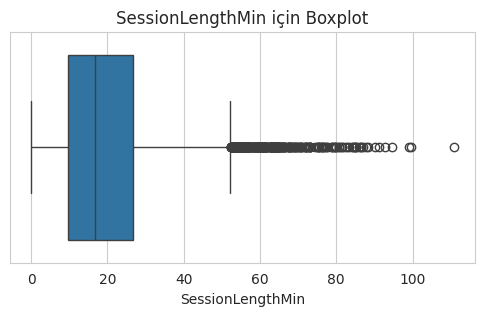

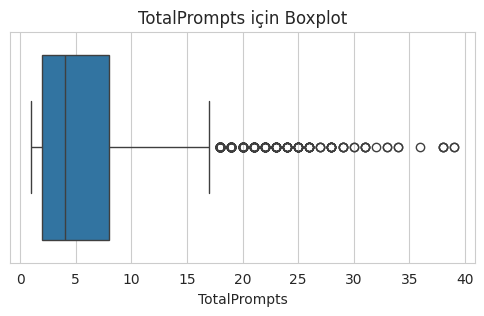

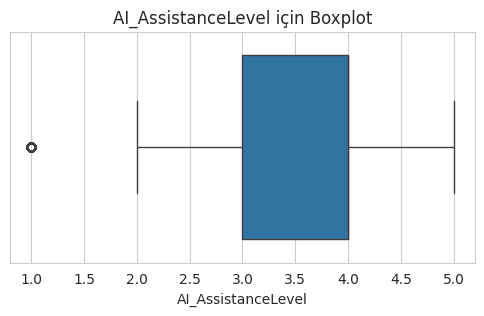

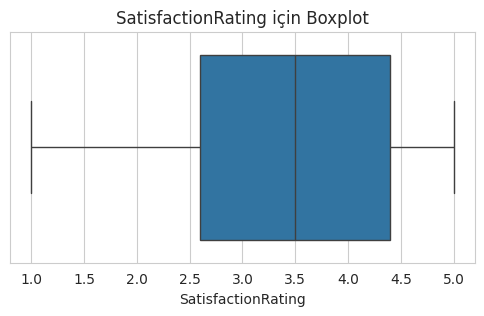

In [16]:
#aykırı değer analizi
numeric_cols = [
    'SessionLengthMin',
    'TotalPrompts',
    'AI_AssistanceLevel',
    'SatisfactionRating'
]

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'{col} için Boxplot')
    plt.show()

In [17]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'{col}: {len(outliers)} aykırı değer')   #IQR ile aykırı değer sayıları

SessionLengthMin: 302 aykırı değer
TotalPrompts: 265 aykırı değer
AI_AssistanceLevel: 241 aykırı değer
SatisfactionRating: 0 aykırı değer


In [18]:
"""
Boxplot grafikleri incelendiğinde 'SessionLengthMin' ve TotalPrompts değişkenlerinde yüksek değerlere sahip gözlemler aykırı değer olarak görünmektedir.
Bununla birlikte bu değerler veri giriş hatası değil, yoğun kullanım davranışını temsil edebilecek gerçek gözlemler olarak değerlendirilmiştir.

'AI_AssistanceLevel' değişkeninde 1 seviyesinde az sayıda gözlem aykırı değer olarak görünmektedir.
Ancak değişkenin doğal ölçeği 1-5 aralığında olduğundan bu gözlemler geçerli kullanıcı davranışlarını temsil etmektedir ve veri setinden çıkarılmamıştır.

'SatisfactionRating' değişkeni de 1-5 aralığında dağıldığından belirgin bir aykırı değer içermemektedir.

Sonuç olarak aykırı değerler veri setinde korunmuş ve modelleme sürecinde olduğu gibi kullanılmıştır.
"""

"\nBoxplot grafikleri incelendiğinde 'SessionLengthMin' ve TotalPrompts değişkenlerinde yüksek değerlere sahip gözlemler aykırı değer olarak görünmektedir.\nBununla birlikte bu değerler veri giriş hatası değil, yoğun kullanım davranışını temsil edebilecek gerçek gözlemler olarak değerlendirilmiştir.\n\n'AI_AssistanceLevel' değişkeninde 1 seviyesinde az sayıda gözlem aykırı değer olarak görünmektedir.\nAncak değişkenin doğal ölçeği 1-5 aralığında olduğundan bu gözlemler geçerli kullanıcı davranışlarını temsil etmektedir ve veri setinden çıkarılmamıştır.\n\n'SatisfactionRating' değişkeni de 1-5 aralığında dağıldığından belirgin bir aykırı değer içermemektedir.\n\nSonuç olarak aykırı değerler veri setinde korunmuş ve modelleme sürecinde olduğu gibi kullanılmıştır.\n"

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
numeric_features = [
    'SessionLengthMin',
    'TotalPrompts',
    'AI_AssistanceLevel',
    'SatisfactionRating'
]

scaler = StandardScaler()

scaled_values = scaler.fit_transform(df[numeric_features])


scaled_df = pd.DataFrame(
    scaled_values,
    columns=numeric_features
)

scaled_df.head()

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating
0,0.817000,1.160044,-1.491799,-2.114786
1,-0.486195,0.084435,-0.483486,-1.240105
2,-0.045081,-0.130686,-0.483486,-0.103020
3,-1.161900,-0.991173,-0.483486,0.071916
4,0.595364,0.729800,-0.483486,-0.452892


In [25]:
scaled_df.mean(), scaled_df.std()

(SessionLengthMin     -3.836931e-17
 TotalPrompts          1.278977e-17
 AI_AssistanceLevel    1.968203e-16
 SatisfactionRating   -4.504841e-16
 dtype: float64,
 SessionLengthMin      1.00005
 TotalPrompts          1.00005
 AI_AssistanceLevel    1.00005
 SatisfactionRating    1.00005
 dtype: float64)

In [ ]:
""" Ölçekleme İşlemi

Sayısal değişkenler farklı ölçeklerde bulunduğu için StandardScaler yöntemi kullanılarak standartlaştırılmıştır.
Ölçekleme işlemi sonucunda değişkenlerin ortalaması yaklaşık 0, standart sapması yaklaşık 1 olacak şekilde dönüştürülmüştür.
Bu işlem özellikle Logistic Regression ve KNN gibi ölçeğe duyarlı modeller için uygulanmıştır."""


In [42]:
df['PromptDensity'] = df['TotalPrompts'] / df['SessionLengthMin']


df['EngagementScore'] = (
    df['SessionLengthMin'] *
    df['AI_AssistanceLevel'] *
    df['SatisfactionRating']
)

In [27]:
df[['PromptDensity', 'EngagementScore']].head()

,PromptDensity,EngagementScore
0,0.352564,62.400
1,0.458365,78.540
2,0.260146,190.278
3,0.270270,38.850
4,0.320057,244.644


In [28]:
correlations = df_encoded.corr()['UsedAgain'].sort_values(ascending=False)

correlations.head(10)

,UsedAgain
UsedAgain,1.000000
FinalOutcome_Idea Drafted,0.117255
TaskType_Coding,0.038773
TaskType_Writing,0.025851
Discipline_History,0.013242
StudentLevel_High School,0.007716
TotalPrompts,0.006690
Discipline_Computer Science,0.005154
Discipline_Engineering,0.004923
SessionLengthMin,0.004908


In [29]:
correlations.tail(10)

,UsedAgain
StudentLevel_Undergraduate,-0.003519
Discipline_Business,-0.008217
SatisfactionRating,-0.009353
AI_AssistanceLevel,-0.010005
TaskType_Homework Help,-0.021487
Discipline_Math,-0.022949
TaskType_Studying,-0.027276
TaskType_Research,-0.031193
FinalOutcome_Gave Up,-0.187997
FinalOutcome_Confused,-0.293381


In [ ]:
""" Korelasyon Analizi Yorumu

Korelasyon analizi sonucunda `FinalOutcome_Idea Drafted` değişkeninin hedef değişkenle pozitif yönde en yüksek ilişkiye sahip olduğu görülmüştür.
Buna karşılık `FinalOutcome_Confused` ve `FinalOutcome_Gave Up` değişkenleri negatif korelasyona sahiptir.
Bu sonuçlar, oturum sonunda olumlu sonuç elde eden kullanıcıların yapay zekâ asistanını tekrar kullanma eğiliminde olduğunu göstermektedir."""


In [44]:
X = df_encoded.drop('UsedAgain', axis=1)
y = df_encoded['UsedAgain']

X.shape, y.shape

((10000, 22), (10000,))

In [45]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((6000, 22), (2000, 22), (2000, 22))

In [ ]:
"""Model için giriş değişkenleri X, hedef değişken ise y (UsedAgain) olarak belirlenmiştir.
Veri seti eğitim, doğrulama ve test kümelerine ayrılmış; test kümesi için %20, doğrulama kümesi için kalan verinin %25’i kullanılmıştır.
Böylece eğitim kümesi 6000, doğrulama kümesi 2000 ve test kümesi 2000 gözlemden oluşmuştur.
Sınıf dağılımını korumak amacıyla veri bölme işlemlerinde 'stratify' parametresi kullanılmıştır."""

In [48]:
log_reg = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
tree = DecisionTreeClassifier(random_state=42)

In [49]:
log_reg.fit(X_train, y_train)

log_pred = log_reg.predict(X_val)

accuracy_score(y_val, log_pred)

0.756

In [50]:
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_val)

accuracy_score(y_val, knn_pred)

0.671

In [51]:
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_val)

accuracy_score(y_val, tree_pred)

0.646

In [52]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Validation Accuracy': [0.756, 0.671, 0.646]
})

model_results

,Model,Validation Accuracy
0,Logistic Regression,0.756
1,KNN,0.671
2,Decision Tree,0.646


In [ ]:
"""Sonuçlara göre en yüksek doğruluk değerini Logistic Regression modeli elde etmiştir.
Logistic Regression modeli doğrulama verisindeki gözlemlerin yaklaşık %75.6’sını doğru sınıflandırmıştır.
Bu nedenle sonraki aşamalarda hiperparametre optimizasyonu ve test değerlendirmesi için bu model seçilmiştir."""

In [54]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_score_

({'C': 10, 'solver': 'lbfgs'}, np.float64(0.7538333333333334))

In [ ]:
""" Hiperparametre Optimizasyonu

En iyi performansı veren Logistic Regression modeli için GridSearchCV kullanılarak basit bir hiperparametre optimizasyonu yapılmıştır.
 `C` ve `solver` parametreleri farklı değerlerle denenmiş, 5 katlı çapraz doğrulama uygulanmıştır.
 En iyi sonuç `C=10` ve `solver='lbfgs'` parametreleri ile elde edilmiş ve çapraz doğrulama doğruluğu yaklaşık %75.38 olarak bulunmuştur."""


In [55]:

best_model = LogisticRegression(C=10, solver='lbfgs', max_iter=5000)

best_model.fit(X_train, y_train)


y_test_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

accuracy, precision, recall, f1

(0.7425, 0.7946194225721784, 0.8570417551309271, 0.8246510044262854)

In [56]:
cm = confusion_matrix(y_test, y_test_pred)
cm

array([[ 274,  313],
       [ 202, 1211]])

In [57]:
classification_report(y_test, y_test_pred)

'              precision    recall  f1-score   support\n\n       False       0.58      0.47      0.52       587\n        True       0.79      0.86      0.82      1413\n\n    accuracy                           0.74      2000\n   macro avg       0.69      0.66      0.67      2000\nweighted avg       0.73      0.74      0.73      2000\n'

In [ ]:
"""Hiperparametre optimizasyonu sonrasında seçilen en iyi model test kümesi üzerinde değerlendirilmiştir.
 Logistic Regression modeli test verisi üzerinde %74.25 doğruluk, %79.46 precision, %85.70 recall ve %82.47 F1-score elde etmiştir.
 Confusion matrix sonuçlarına göre model, yapay zekâ asistanını tekrar kullanacak kullanıcıları başarılı bir şekilde tahmin etmektedir.
 Test doğruluğunun doğrulama doğruluğuna yakın olması modelin aşırı öğrenme eğiliminin düşük olduğunu göstermektedir."""

In [ ]:
"""Sonuç ve Değerlendirme

Bu projede kullanıcıların yapay zekâ asistanını tekrar kullanıp kullanmayacağını tahmin etmek amacıyla uçtan uca bir makine öğrenmesi süreci uygulanmıştır.
Veri inceleme, eksik değer analizi, encoding, aykırı değer analizi, ölçekleme, öznitelik mühendisliği, öznitelik seçimi, veri bölme, model eğitimi ve
hiperparametre optimizasyonu adımları gerçekleştirilmiştir.

Karşılaştırılan modeller arasında en yüksek performansı Logistic Regression modeli göstermiştir.
Test kümesinde yaklaşık %74 doğruluk elde edilmesi modelin daha önce görmediği veriler üzerinde de tutarlı çalıştığını göstermektedir.
Korelasyon analizinde FinalOutcome_Idea Drafted değişkeni tekrar kullanım davranışıyla pozitif ilişki gösterirken,
FinalOutcome_Confused değişkeni negatif ilişki göstermiştir.

Modelin temel sınırlılığı veri setinin sentetik ve davranışsal özellikler içermesi nedeniyle kullanıcı davranışının tüm yönlerini temsil etmeyebilmesidir.
Daha fazla kullanıcı bilgisi ve gerçek kullanım verisi ile model performansı artırılabilir."""

In [58]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
14,TaskType_Coding,0.262061
11,Discipline_History,0.135896
4,PromptDensity,0.108576
9,Discipline_Computer Science,0.107694
15,TaskType_Homework Help,0.101012
13,Discipline_Psychology,0.071268
17,TaskType_Studying,0.065525
7,StudentLevel_Undergraduate,0.050343
18,TaskType_Writing,0.047190
16,TaskType_Research,0.033889


In [59]:
coef_df.tail(10)

,Feature,Coefficient
3,SatisfactionRating,0.012279
0,SessionLengthMin,0.009228
5,EngagementScore,-0.000166
2,AI_AssistanceLevel,-0.000700
1,TotalPrompts,-0.017094
8,Discipline_Business,-0.017757
21,FinalOutcome_Idea Drafted,-0.069643
12,Discipline_Math,-0.146610
19,FinalOutcome_Confused,-1.832539
20,FinalOutcome_Gave Up,-1.858628


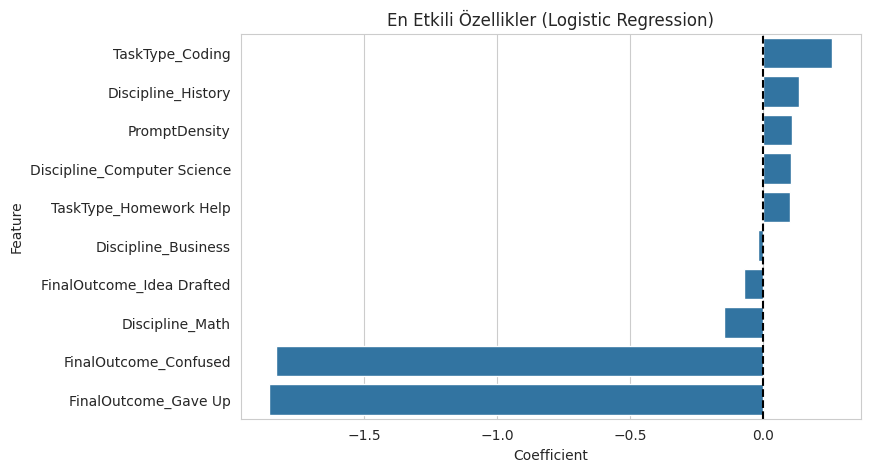

In [60]:
top_features = pd.concat([
    coef_df.head(5),
    coef_df.tail(5)
])

plt.figure(figsize=(8,5))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title('En Etkili Özellikler (Logistic Regression)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [ ]:
""" Model Açıklanabilirliği

En iyi performansı veren Logistic Regression modeli için katsayılar incelenerek basit bir açıklanabilirlik analizi yapılmıştır.
Pozitif katsayıya sahip değişkenler kullanıcının yapay zekâ asistanını tekrar kullanma olasılığını artırırken,
negatif katsayıya sahip değişkenler bu olasılığı azaltmaktadır.

Model sonuçlarına göre `TaskType_Coding` değişkeni en yüksek pozitif katsayıya sahiptir.
Ayrıca `Discipline_History`, `PromptDensity`, `Discipline_Computer Science` ve `TaskType_Homework Help` değişkenleri de tekrar kullanım olasılığını artıran
önemli özellikler arasında yer almaktadır.

Negatif tarafta ise `FinalOutcome_Gave Up` ve `FinalOutcome_Confused` değişkenleri en güçlü etkiye sahiptir.
 Bu sonuç, oturum sonunda pes eden veya kafası karışan kullanıcıların yapay zekâ asistanını tekrar kullanma eğiliminin belirgin şekilde azaldığını göstermektedir.
 `Discipline_Math` değişkeni de daha düşük tekrar kullanım olasılığı ile ilişkilidir.

Bu analiz, kullanıcı deneyiminin özellikle oturum sonundaki algısının tekrar kullanım davranışı üzerinde önemli bir etkisi olduğunu göstermektedir."""
